# Elementos de Probabilidad

## Problema 1: Funciones Características

Una **función característica** de una variable aleatoria $X$ se define como

$$
\phi_X(t) = E[e^{itX}], \qquad t \in \mathbb{R}.
$$

Contiene la misma información que la PMF o la PDF, pero es especialmente útil
porque:

- siempre existe, aun cuando la MGF no exista;
- determina de forma única la distribución de $X$;
- transforma sumas de variables independientes en productos:
  $\phi_{X+Y}(t) = \phi_X(t)\phi_Y(t)$;
- permite recuperar momentos cuando existen, pues
  $\phi_X^{(n)}(0) = i^n E[X^n]$;
- es fundamental en teoremas de convergencia como el teorema de continuidad de
  Lévy y en demostraciones del teorema del límite central.

Otras propiedades importantes son:

- $\phi_X(0) = 1$;
- $|\phi_X(t)| \leq 1$;
- $\phi_X(-t) = \phi_X(t)^*$ para variables reales;
- si $Y = aX + b$, entonces
  $\phi_Y(t) = e^{itb}\phi_X(at)$.

### Bernoulli

Sea $X \sim Bern(p)$, de manera que

$$
P(X=1)=p, \qquad P(X=0)=1-p.
$$

Entonces

$$
\phi_X(t) = E[e^{itX}] = (1-p)e^{i t \cdot 0} + p e^{i t \cdot 1}
= 1-p+pe^{it}.
$$

Derivando,

$$
\phi_X^{(n)}(t) = p\, i^n e^{it},
$$

y por tanto

$$
\phi_X^{(n)}(0)=p\,i^n.
$$

Usando la relación entre derivadas y momentos,

$$
E[X^n] = \frac{\phi_X^{(n)}(0)}{i^n} = p, \qquad n \ge 1.
$$

Esto coincide con la observación elemental de que, para una Bernoulli,
$X^n = X$ para todo $n \ge 1$.

### Distribución normal

Sea ahora $X \sim \mathcal{N}(\mu,\sigma^2)$. Su PDF es

$$
f(x)=\frac{1}{\sigma\sqrt{2\pi}}
\exp\left[-\frac{(x-\mu)^2}{2\sigma^2}\right].
$$

La función característica se obtiene de la integral

$$
\phi_X(t)=\int_{-\infty}^{\infty} e^{itx} f(x)\,dx,
$$

y, completando cuadrados en el exponente, se llega a

$$
\phi_X(t)=\exp\left(i\mu t-\frac{\sigma^2 t^2}{2}\right).
$$

Los momentos se obtienen derivando en $t=0$:

$$
E[X^n] = \frac{\phi_X^{(n)}(0)}{i^n}.
$$

La forma cerrada de los **momentos crudos** es

$$ E[X^n] =
\sum_{k=0}^{\lfloor n/2 \rfloor}
\frac{n!}{2^k k!(n-2k)!}\,
\sigma^{2k}\mu^{\,n-2k}.
$$

Los primeros casos son

$$
E[X]=\mu,
$$

$$
E[X^2]=\mu^2+\sigma^2,
$$

$$
E[X^3]=\mu^3+3\mu\sigma^2,
$$

$$
E[X^4]=\mu^4+6\mu^2\sigma^2+3\sigma^4.
$$

Si en lugar de momentos crudos se toman momentos **centrales** de
$X-\mu \sim \mathcal{N}(0,\sigma^2)$, entonces

$$
E[(X-\mu)^{2m+1}] = 0,
$$

$$
E[(X-\mu)^{2m}] = (2m-1)!!\,\sigma^{2m}.
$$

### Código

In [2]:
import numpy as np
from math import factorial

def phi_bernoulli(t, p):
    return 1 - p + p * np.exp(1j * t)

def bernoulli_moment(n, p):
    # Para Bernoulli, X^n = X si n >= 1
    return p if n >= 1 else 1.0

def phi_normal(t, mu, sigma):
    return np.exp(1j * mu * t - 0.5 * sigma**2 * t**2)

def normal_moment(n, mu, sigma):
    total = 0.0
    for k in range(n // 2 + 1):
        total += (
            factorial(n)
            / (2**k * factorial(k) * factorial(n - 2 * k))
            * sigma**(2 * k)
            * mu**(n - 2 * k)
        )
    return total

p = 0.3
mu = 1.2
sigma = 0.8
tvals = np.linspace(-4, 4, 5)

print("phi_Bernoulli(t):", phi_bernoulli(tvals, p))
print("Momentos Bernoulli:", [bernoulli_moment(n, p) for n in range(1, 6)])
print("phi_Normal(t):", phi_normal(tvals, mu, sigma))
print("Momentos Normal:", [normal_moment(n, mu, sigma) for n in range(1, 5)])

phi_Bernoulli(t): [0.50390691+0.22704075j 0.57515595-0.27278923j 1.        +0.j
 0.57515595+0.27278923j 0.50390691-0.22704075j]
Momentos Bernoulli: [0.3, 0.3, 0.3, 0.3, 0.3]
phi_Normal(t): [ 5.22895928e-04+0.0059531j  -2.05022958e-01-0.18780396j
  1.00000000e+00+0.j         -2.05022958e-01+0.18780396j
  5.22895928e-04-0.0059531j ]
Momentos Normal: [1.2, 2.08, 4.032, 8.832]


## Problema 2: Multivariable Aleatoria

La PDF conjunta es

$$
f_{X,Y}(x,y) =
\begin{cases}
c, & x^2+y^2 \le 1, \\
0, & \text{de lo contrario}.
\end{cases}
$$

Esto describe una distribución uniforme sobre el disco unitario.

### 1. Encontrar $c$

La normalización exige

$$
\iint_{\mathbb{R}^2} f_{X,Y}(x,y)\,dx\,dy = 1.
$$

Como el soporte es el disco de radio $1$,

$$
c \cdot \textrm{Area}(\textrm{disco}) = c\pi = 1,
$$

de donde

$$
c = \frac{1}{\pi}.
$$

### 2. Densidades marginales

Para $f_X(x)$, fijamos $x$ y dejamos variar $y$ en el intervalo permitido
por el disco:

$$
-\sqrt{1-x^2} \le y \le \sqrt{1-x^2}, \qquad |x|\le 1.
$$

Entonces

$$
f_X(x)=\int_{-\infty}^{\infty} f_{X,Y}(x,y)\,dy
= \int_{-\sqrt{1-x^2}}^{\sqrt{1-x^2}} \frac{1}{\pi}\,dy
= \frac{2}{\pi}\sqrt{1-x^2},
$$

para $|x|\le 1$, y $f_X(x)=0$ fuera de ese intervalo. Es decir,

$$
f_X(x)=
\begin{cases}
\dfrac{2}{\pi}\sqrt{1-x^2}, & |x|\le 1, \\
0, & \text{de lo contrario}.
\end{cases}
$$

Por simetría,

$$
f_Y(y)=
\begin{cases}
\dfrac{2}{\pi}\sqrt{1-y^2}, & |y|\le 1, \\
0, & \text{de lo contrario}.
\end{cases}
$$

### 3. Independencia

No, $X$ y $Y$ **no** son independientes.

Si fueran independientes, debería cumplirse

$$
f_{X,Y}(x,y)=f_X(x)f_Y(y).
$$

Pero el soporte conjunto es un disco, mientras que el producto
$f_X(x)f_Y(y)$ sería positivo en casi todo el cuadrado $[-1,1]\times[-1,1]$.
Por ejemplo, para $x=y=0.9$,

$$
f_X(0.9)f_Y(0.9) > 0,
$$

pero

$$
0.9^2+0.9^2 = 1.62 > 1,
$$

de modo que

$$
f_{X,Y}(0.9,0.9)=0.
$$

Por lo tanto, no hay independencia.

### 4. Correlación

Por simetría del disco respecto a ambos ejes,

$$
E[X]=0, \qquad E[Y]=0.
$$

Además,

$$
E[XY]
= \iint_{x^2+y^2\le 1} xy \frac{1}{\pi}\,dx\,dy = 0,
$$

porque el integrando $xy$ cambia de signo bajo $x\to -x$ o $y\to -y$, y
el dominio es simétrico.

Entonces

$$
\mathrm{cov}(X,Y)=E[XY]-E[X]E[Y]=0.
$$

Y como la correlación es

$$
\mathrm{corr}(X,Y)=
\frac{\mathrm{cov}(X,Y)}{\sqrt{\mathrm{var}(X)\mathrm{var}(Y)}},
$$

se concluye que

$$
\mathrm{corr}(X,Y)=0.
$$

En resumen: $X$ y $Y$ **no son independientes**, pero sí están
**descorrelacionadas**.

### Código en Python

In [4]:
import numpy as np

def f_xy(x, y):
    inside = x**2 + y**2 <= 1.0
    return np.where(inside, 1.0 / np.pi, 0.0)

def f_x(x):
    inside = np.abs(x) <= 1.0
    return np.where(inside, 2.0 * np.sqrt(1.0 - x**2) / np.pi, 0.0)

def f_y(y):
    inside = np.abs(y) <= 1.0
    return np.where(inside, 2.0 * np.sqrt(1.0 - y**2) / np.pi, 0.0)

rng = np.random.default_rng(20260427)
n = 200_000
theta = rng.uniform(0.0, 2.0 * np.pi, size=n)
r = np.sqrt(rng.uniform(0.0, 1.0, size=n))
x = r * np.cos(theta)
y = r * np.sin(theta)

print("E[X]   =", np.mean(x))
print("E[Y]   =", np.mean(y))
print("E[XY]  =", np.mean(x * y))
print("cov(X,Y) =", np.mean(x * y) - np.mean(x) * np.mean(y))

E[X]   = 0.00013250173922458238
E[Y]   = -0.00014352933349380819
E[XY]  = -0.0003504369529331446
cov(X,Y) = -0.0003504179350468269


## Problema 3: Partículas Cuánticas y Marginales de la Distribución

La PDF conjunta propuesta es

$$
f(x_1, x_2) =
\frac{1}{\pi a^2}
\left(\frac{x_2 - x_1}{a}\right)^2
\exp\left[-\frac{x_1^2 + x_2^2}{a^2}\right].
$$

Equivalentemente,

$$
f(x_1,x_2)=\frac{(x_2-x_1)^2}{\pi a^4}
\exp\left[-\frac{x_1^2+x_2^2}{a^2}\right].
$$

### Normalización

Hay que verificar que

$$
\iint_{\mathbb{R}^2} f(x_1,x_2)\,dx_1\,dx_2 = 1.
$$

Es conveniente usar el cambio de variables

$$
u=\frac{x_1+x_2}{\sqrt{2}}, \qquad
v=\frac{x_2-x_1}{\sqrt{2}},
$$

para el cual

$$
x_1^2+x_2^2=u^2+v^2,
\qquad
(x_2-x_1)^2=2v^2,
\qquad
dx_1\,dx_2=du\,dv.
$$

Entonces

$$ \iint f(x_1,x_2)\,dx_1\,dx_2 =
\frac{1}{\pi a^4}
\iint 2v^2 e^{-(u^2+v^2)/a^2}\,du\,dv.
$$

Separando integrales,

$$
\frac{1}{\pi a^4}
\left(\int_{-\infty}^{\infty} e^{-u^2/a^2}\,du\right)
\left(2\int_{-\infty}^{\infty} v^2 e^{-v^2/a^2}\,dv\right).
$$

Usando las integrales gaussianas estándar,

$$
\int_{-\infty}^{\infty} e^{-u^2/a^2}\,du = a\sqrt{\pi},
$$

$$
\int_{-\infty}^{\infty} v^2 e^{-v^2/a^2}\,dv
= \frac{a^3\sqrt{\pi}}{2}.
$$

Por tanto,

$$
\frac{1}{\pi a^4}(a\sqrt{\pi})
\left(2 \cdot \frac{a^3\sqrt{\pi}}{2}\right)=1.
$$

Sí, $f(x_1,x_2)$ está correctamente normalizada y por lo tanto es una PDF
conjunta válida.

### Distribuciones marginales

Para $X_1$,

$$
f_{X_1}(x_1) =
\int_{-\infty}^{\infty}
\frac{(x_2-x_1)^2}{\pi a^4}
\exp\left[-\frac{x_1^2+x_2^2}{a^2}\right] dx_2.
$$

Sacando los términos que no dependen de $x_2$,

$$
f_{X_1}(x_1) =
\frac{e^{-x_1^2/a^2}}{\pi a^4}
\int_{-\infty}^{\infty} (x_2-x_1)^2 e^{-x_2^2/a^2}\,dx_2.
$$

Expandimos:

$$
(x_2-x_1)^2 = x_2^2 - 2x_1x_2 + x_1^2.
$$

Entonces

$$
\int (x_2-x_1)^2 e^{-x_2^2/a^2}\,dx_2 =
\int x_2^2 e^{-x_2^2/a^2}\,dx_2
-2x_1 \int x_2 e^{-x_2^2/a^2}\,dx_2
+x_1^2 \int e^{-x_2^2/a^2}\,dx_2.
$$

La integral impar vale cero, y las otras dos dan

$$
\int_{-\infty}^{\infty} x_2^2 e^{-x_2^2/a^2}\,dx_2
= \frac{a^3\sqrt{\pi}}{2},
$$

$$
\int_{-\infty}^{\infty} e^{-x_2^2/a^2}\,dx_2 = a\sqrt{\pi}.
$$

Por lo tanto,

$$
f_{X_1}(x_1) =
\frac{e^{-x_1^2/a^2}}{\pi a^4}
\left(
\frac{a^3\sqrt{\pi}}{2} + x_1^2 a\sqrt{\pi}
\right).
$$

Finalmente,

$$
f_{X_1}(x_1) =
\frac{1}{\sqrt{\pi}a}
\left(
\frac{1}{2} + \frac{x_1^2}{a^2}
\right)
e^{-x_1^2/a^2}.
$$

Por simetría,

$$
f_{X_2}(x_2) =
\frac{1}{\sqrt{\pi}a}
\left(
\frac{1}{2} + \frac{x_2^2}{a^2}
\right)
e^{-x_2^2/a^2}.
$$

### ¿Son independientes?

No. La PDF conjunta no factoriza como $f_{X_1}(x_1)f_{X_2}(x_2)$, y además el
factor $(x_2-x_1)^2$ acopla explícitamente a ambas variables. Otra forma de
verlo es que la distribución condicional de $X_1$ depende de $x_2$, como se
obtiene a continuación.

### Distribución condicional

Para variables continuas, el objeto correcto es la **densidad condicional**

$$
f_{X_1|X_2}(x_1|x_2)
= \frac{f(x_1,x_2)}{f_{X_2}(x_2)}.
$$

Sustituyendo las expresiones anteriores,

$$
f_{X_1|X_2}(x_1|x_2) =
\frac{(x_2-x_1)^2}{\sqrt{\pi}\,a^3
\left(\frac{1}{2}+\frac{x_2^2}{a^2}\right)}
\exp\left(-\frac{x_1^2}{a^2}\right).
$$

Como depende explícitamente de $x_2$, queda claro que $X_1$ y $X_2$ no
son independientes.

Tomando $a=1$, las curvas pedidas para
$x_2=0,\frac{1}{2},1,2$ son:

![Densidades condicionales del problema 3](figures/problema3_condicionales.png)

Se observa que:

- para $x_2=0$, la densidad es simétrica y se anula en $x_1=0$ por el factor
  $(x_2-x_1)^2$;
- al aumentar $x_2$, la densidad se deforma porque se penaliza la región
  cercana a $x_1=x_2$;
- la gaussiana $e^{-x_1^2/a^2}$ controla el decaimiento para $|x_1|$ grande.

### Código en Python

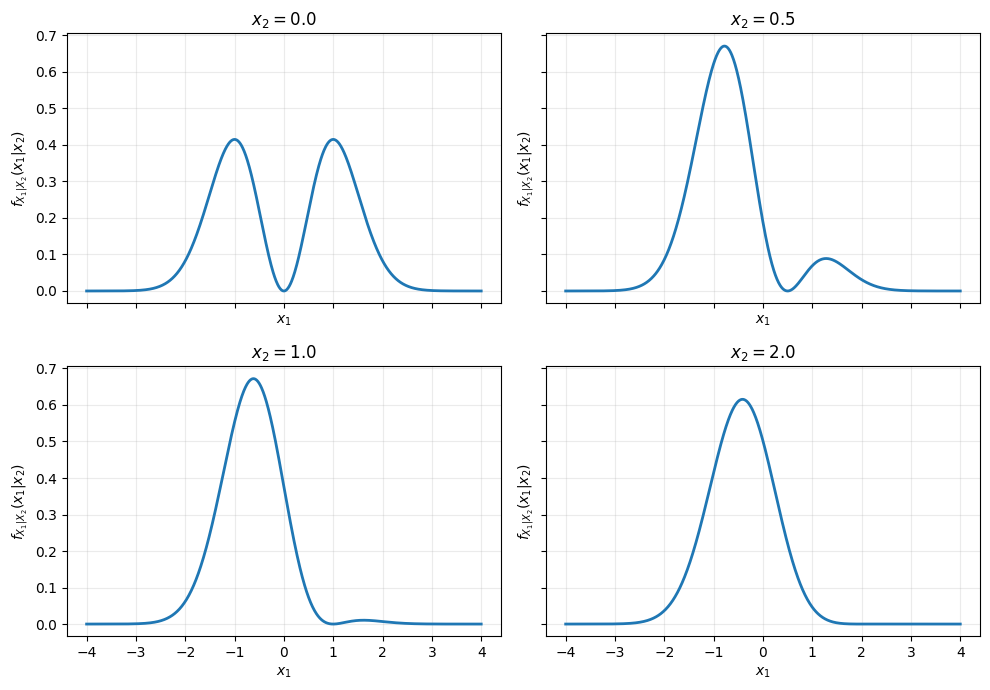

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def joint_pdf(x1, x2, a):
    return ((x2 - x1)**2 / (np.pi * a**4)) * np.exp(-(x1**2 + x2**2) / a**2)

def marginal_x(x, a):
    return np.exp(-x**2 / a**2) * (0.5 + x**2 / a**2) / (np.sqrt(np.pi) * a)

def conditional_x1_given_x2(x1, x2, a):
    denom = np.sqrt(np.pi) * a**3 * (0.5 + x2**2 / a**2)
    return ((x2 - x1)**2 / denom) * np.exp(-x1**2 / a**2)

a = 1.0
x = np.linspace(-4, 4, 1000)
x2_values = [0.0, 0.5, 1.0, 2.0]

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)
axes = axes.ravel()

for ax, x2 in zip(axes, x2_values):
    ax.plot(x, conditional_x1_given_x2(x, x2, a), lw=2)
    ax.set_title(rf"$x_2={x2}$")
    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$f_{X_1|X_2}(x_1|x_2)$")
    ax.grid(alpha=0.25)

fig.tight_layout()
plt.show()

## Problema 4: Teoría Cinética de Gases

La energía cinética es

$$
T=\frac{1}{2}(v_x^2+v_y^2+v_z^2),
$$

con $v_x,v_y,v_z \sim \mathcal{N}(0,1)$ independientes.

### 1. Demostrar que $E[T]=3/2$

Por linealidad del valor esperado,

$$
E[T]
= \frac{1}{2}\left(E[v_x^2]+E[v_y^2]+E[v_z^2]\right).
$$

Para una normal $\mathcal{N}(0,1)$,

$$
E[v_i^2]=\mathrm{var}(v_i)=1.
$$

Así,

$$
E[T]=\frac{1}{2}(1+1+1)=\frac{3}{2}.
$$

Además, como $v_x^2+v_y^2+v_z^2 \sim \chi^2_3$, se tiene

$$
T \sim \Gamma\left(\frac{3}{2},1\right),
$$

con densidad

$$
f_T(t)=\frac{2}{\sqrt{\pi}}\sqrt{t}\,e^{-t}, \qquad t\ge 0.
$$

### 2. Histogramas para $N=5,50,1000$

Los histogramas generados con una corrida reproducible se muestran abajo. En
rojo se sobrepone la densidad teórica $f_T(t)$.

![Histogramas del problema 4](figures/problema4_histogramas.png)

En esta corrida, los promedios muestrales fueron:

- $N=5$: $\bar T \approx 1.633$
- $N=50$: $\bar T \approx 1.293$
- $N=1000$: $\bar T \approx 1.506$

La **ley débil de los grandes números** dice que, para cualquier
$\varepsilon>0$,

$$
P\left(\left|\bar T_N-\frac{3}{2}\right|>\varepsilon\right)\to 0
\qquad \text{cuando } N\to\infty.
$$

Esto no implica que cada muestra pequeña esté cerca de $3/2$, sino que la
probabilidad de desviaciones grandes disminuye con $N$. En los histogramas se
ve exactamente esa tendencia:

- con $N=5$, la muestra es demasiado pequeña y la forma es muy irregular;
- con $N=50$, la distribución empírica ya sugiere la forma correcta, pero aún
  hay fluctuaciones visibles;
- con $N=1000$, el histograma es mucho más suave y el promedio muestral queda
  muy cerca de $1.5$.

### 3. Promedio acumulativo y ley fuerte de los grandes números

Si definimos

$$
\bar T_N = \frac{1}{N}\sum_{k=1}^N T_k,
$$

entonces la **ley fuerte de los grandes números** establece que

$$
\bar T_N \to E[T]=\frac{3}{2}
\qquad \text{casi seguramente}.
$$

El gráfico del promedio acumulado para una trayectoria de $10^4$ muestras es:

![Promedio acumulado del problema 4](figures/problema4_promedio_acumulado.png)

En esta realización, el valor final fue

$$
\bar T_{10000} \approx 1.499.
$$

El comportamiento es el esperado: al principio hay oscilaciones grandes, pero
conforme aumenta $N$, el promedio acumulado se estabiliza alrededor de
$3/2$. Una sola trayectoria no constituye una demostración del teorema, pero
sí es completamente consistente con la convergencia casi segura predicha por la
ley fuerte.

### Código en Python

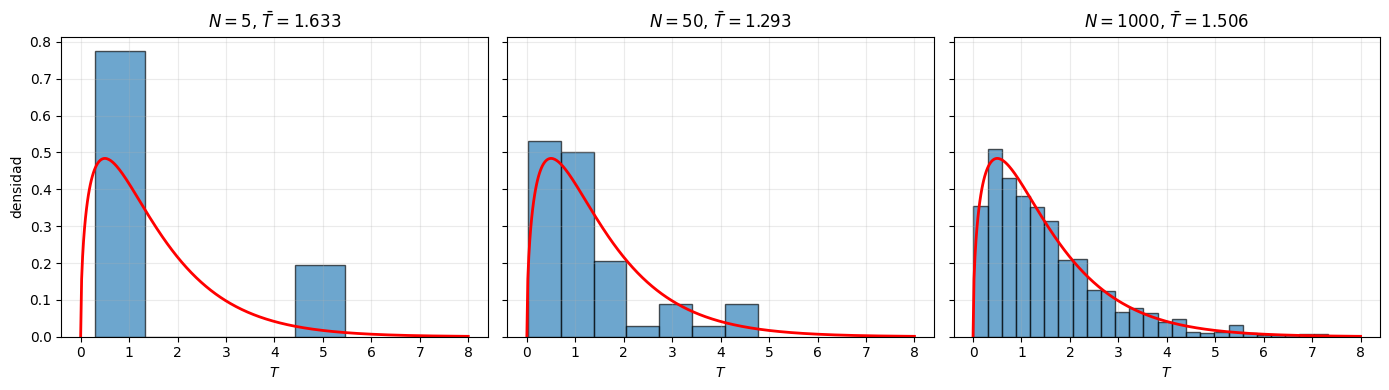

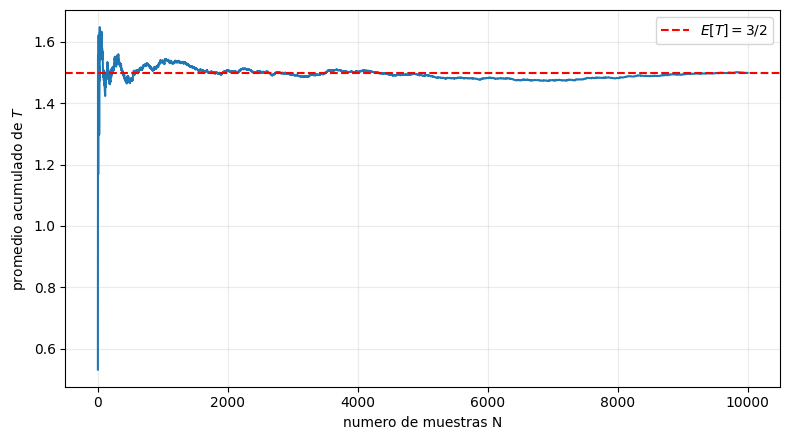

Promedio final: 1.4990014308340092


In [8]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(20260427)

def kinetic_energy_samples(n, rng):
    v = rng.normal(0.0, 1.0, size=(n, 3))
    return 0.5 * np.sum(v**2, axis=1)

def kinetic_energy_pdf(t):
    return (2.0 / np.sqrt(np.pi)) * np.sqrt(t) * np.exp(-t)

# Histogramas
sample_sizes = [5, 50, 1000]
t = np.linspace(0.0, 8.0, 400)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, n in zip(axes, sample_sizes):
    T = kinetic_energy_samples(n, rng)
    bins = min(25, max(5, int(np.sqrt(n))))
    ax.hist(T, bins=bins, density=True, alpha=0.65, edgecolor="black")
    ax.plot(t, kinetic_energy_pdf(t), color="red", lw=2)
    ax.set_title(rf"$N={n}$, $\bar T={np.mean(T):.3f}$")
    ax.set_xlabel(r"$T$")
    ax.grid(alpha=0.25)

axes[0].set_ylabel("densidad")
fig.tight_layout()
plt.show()

# Promedio acumulado
Ncum = 10_000
T = kinetic_energy_samples(Ncum, rng)
cummean = np.cumsum(T) / np.arange(1, Ncum + 1)

plt.figure(figsize=(8, 4.5))
plt.plot(np.arange(1, Ncum + 1), cummean, lw=1.5)
plt.axhline(1.5, color="red", ls="--", label=r"$E[T]=3/2$")
plt.xlabel("numero de muestras N")
plt.ylabel(r"promedio acumulado de $T$")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

print("Promedio final:", cummean[-1])